# Zero Cutoff Extrapolation

Heisenberg propagation, being a classical simulation method, results in exponentially growing operator representations. To keep the computation tractable, propagations rely on truncating the operator representation. Pruning can be done using methods such as coefficient cutoff and weight cutoff. Both introduce a systematic bias that can be mitigated by sweeping over truncation strengths and extrapolating to the zero-truncation limit, analogous to zero-noise extrapolation (ZNE).

propaq provides two ZCE classes, `CoefficientCutoffExtrapolator` and `WeightCutoffExtrapolator`, which sweep over coefficient cutoff values and integer weight cutoff values, respectively, and extrapolate to the zero-truncation limit. In this notebook, we'll demonstrate the use of coefficient cutoff extrapolation on a simple model.

For this example we use the same setup as the ZNE notebook: the ground-state energy of a hydrogen molecule estimated via the LUCJ ansatz.

In [ ]:
import ffsim
import matplotlib.pyplot as plt; plt.rcParams.update({"font.family": "serif", "font.size": 12})
import numpy as np
import pyscf
import pyscf.cc
import pyscf.mcscf
import qiskit
from qiskit import QuantumCircuit, QuantumRegister
from qiskit.providers.fake_provider import GenericBackendV2

atom: str = "H"
natoms: int = 2
nlayers: int = 1

def generate_linear_geometry(atom: str, natoms: int, atomic_distance: float = 1.0) -> str:
    """Returns a linear Hydrogen chain geometry for use in PySCF molecule construction.

    Args:
        natoms: Number of Hydrogen atoms in the chain.
        atomic_distance: Equal spacing between Hydrogen atoms.
    """
    return "; ".join([f"{atom} 0 0 {i * atomic_distance}" for i in range(natoms)])

spin_sq = 0

mol = pyscf.gto.Mole()
mol.build(
    atom=generate_linear_geometry(atom, natoms),
    basis="sto-6g",
)

n_frozen = 0
active_space = range(n_frozen, mol.nao_nr())

scf = pyscf.scf.RHF(mol).run()
norb = len(active_space)
n_electrons = int(sum(scf.mo_occ[active_space]))
n_alpha = (n_electrons + mol.spin) // 2
n_beta  = (n_electrons - mol.spin) // 2
nelec = (n_alpha, n_beta)
cas = pyscf.mcscf.CASCI(scf, norb, nelec)
mo  = cas.sort_mo(active_space, base=0)
hcore, nuclear_repulsion_energy = cas.get_h1cas(mo)
eri = pyscf.ao2mo.restore(1, cas.get_h2cas(mo), norb)

print(f"norb = {norb}")
print(f"nelec = {nelec}")

ccsd = pyscf.cc.CCSD(
    scf, frozen=[i for i in range(mol.nao_nr()) if i not in active_space]
).run()
t1 = ccsd.t1
t2 = ccsd.t2

import warnings
from qiskit.transpiler import CouplingMap
warnings.formatwarning = lambda msg, *args, **kwargs: f"Warning: {msg}\n"

n_reps   = nlayers
pairs_aa = [(p, q) for p in range(norb) for q in range(p + 1, norb)]
pairs_ab = None

coupling_map = CouplingMap.from_full(2 * norb, bidirectional=True)
backend = GenericBackendV2(
    2 * norb,
    coupling_map=coupling_map,
    basis_gates=["cp", "xx_plus_yy", "p", "x", "swap"],
)

try:
    pass_manager, pairs_ab = ffsim.qiskit.generate_lucj_pass_manager(
        backend=backend,
        norb=norb,
        connectivity="heavy-hex",
        interaction_pairs=(pairs_aa, pairs_ab),
        optimization_level=3,
    )
    print("Unable to generate ffsim pass manager")
except RuntimeError:
    pass_manager = None

ucj_op = ffsim.UCJOpSpinBalanced.from_t_amplitudes(
    t2=t2, t1=t1, n_reps=n_reps,
    interaction_pairs=(pairs_aa, pairs_ab),
    optimize=True,
    options=dict(maxiter=10_000),
)

qubits  = QuantumRegister(2 * norb, name="q")
circuit = QuantumCircuit(qubits)
circuit.append(ffsim.qiskit.PrepareHartreeFockJW(norb, nelec), qubits)
circuit.append(ffsim.qiskit.UCJOpSpinBalancedJW(ucj_op), qubits)

if pass_manager is not None:
    compiled = pass_manager.run(circuit)
else:
    compiled = qiskit.transpile(
        circuit, backend=backend, optimization_level=3,
        initial_layout=list(range(2 * norb)),
    )

print(f"Number of qubits: {compiled.num_qubits}")
print(f"Gate counts: {compiled.count_ops()}")
compiled.draw(fold=-1)

Build the Hamiltonian for the hydrogen molecule.

In [42]:
from qiskit_nature.second_q.hamiltonians import ElectronicEnergy
from qiskit_nature.second_q.operators import ElectronicIntegrals
from qiskit_nature.second_q.mappers import JordanWignerMapper
from qiskit.quantum_info import SparsePauliOp

h2e_phys = np.einsum("prqs->pqrs", eri)
elec_ints = ElectronicIntegrals.from_raw_integrals(hcore, h2e_phys)
elec_hamiltonian = ElectronicEnergy(elec_ints)
mapper = JordanWignerMapper()
hamiltonian = mapper.map(elec_hamiltonian.second_q_op())
hamiltonian = (hamiltonian + SparsePauliOp("I" * (2 * norb), coeffs=[nuclear_repulsion_energy])).simplify()
sorted_indices = np.argsort(-np.abs(hamiltonian.coeffs))
hamiltonian = hamiltonian[sorted_indices]
print(f"Hamiltonian has {len(hamiltonian)} Pauli terms.")

Hamiltonian has 15 Pauli terms.


Convert to a `MajoranaTermSum` and build the circuit.

In [43]:
from propaq.datatypes import MajoranaTermSum
from propaq.propagators import MajoranaPropagator
from propaq.circuits import MajoranaCircuit
from propaq.noise import TruncationPolicy
from propaq.extrapolators import CoefficientCutoffExtrapolator, WeightCutoffExtrapolator

obs_ham = MajoranaTermSum.from_sparse_pauli_op(hamiltonian)
mc = MajoranaCircuit.from_qiskit(compiled.copy(), n_modes=4 * norb)

## Coefficient Cutoff Extrapolation

The coefficient cutoff discards terms whose absolute coefficient falls below a threshold $\varepsilon$. A larger $\varepsilon$ discards more terms and introduces more bias, and extrapolating approximates the zero-truncation limit.

Here we hold the weight cutoff fixed at `weight_cutoff=None` (no weight truncation) and sweep the coefficient cutoff.

Reference (coeff_cutoff=0) : -1.108869 Ha
ZCE extrapolated value     : -1.108831 Ha
CCSD energy                : -1.108873 Ha  (reference)


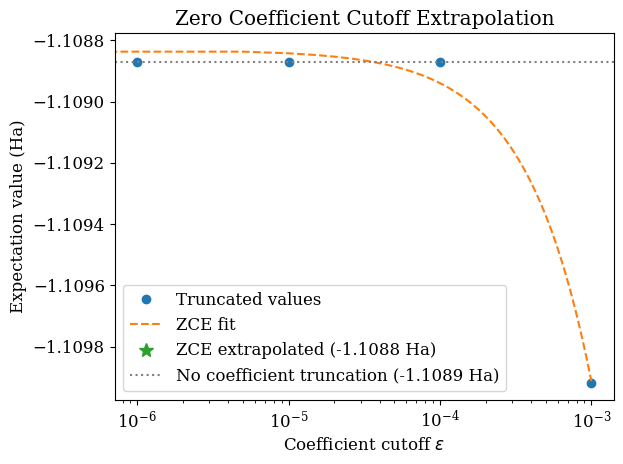

In [44]:
# Reference: no coefficient truncation
prop_exact_coeff = MajoranaPropagator(
    truncation=TruncationPolicy(weight_cutoff=None, coeff_cutoff=0.0),
    n_threads=16,
)
ref_coeff = prop_exact_coeff.expectation_value(obs_ham, mc, initial_state=0).expectation_value

# ZCE: sweep coeff_cutoff from a small value upward (more truncation = more bias)
coeff_cutoff_values = [1e-6, 1e-5, 1e-4, 1e-3]

prop_coeff = MajoranaPropagator(
    truncation=TruncationPolicy(weight_cutoff=None, coeff_cutoff=coeff_cutoff_values[0]),
    n_threads=16,
)

zce_coeff = CoefficientCutoffExtrapolator(
    fitting_fn=lambda eps, a, b: a + b * eps,
    cutoff_values=coeff_cutoff_values,
)

result_coeff = zce_coeff.run(prop_coeff, obs_ham, mc, initial_state=0)

print(f"Reference (coeff_cutoff=0) : {ref_coeff:.6f} Ha")
print(f"ZCE extrapolated value     : {result_coeff.zero_cutoff_value:.6f} Ha")
print(f"CCSD energy                : {ccsd.e_tot:.6f} Ha  (reference)")

fig, ax = plt.subplots()

ax.plot(
    result_coeff.cutoff_values,
    result_coeff.expectation_values,
    'o', label='Truncated values'
)

eps_range = np.linspace(0, max(coeff_cutoff_values), 200)
fit_curve = [zce_coeff.fitting_fn(e, *result_coeff.fit_params) for e in eps_range]
ax.plot(eps_range, fit_curve, '--', label='ZCE fit')

ax.plot(
    0, result_coeff.zero_cutoff_value, '*', markersize=10,
    label=f'ZCE extrapolated ({result_coeff.zero_cutoff_value:.4f} Ha)'
)
ax.axhline(
    ref_coeff, color='gray', linestyle=':',
    label=f'No coefficient truncation ({ref_coeff:.4f} Ha)'
)

ax.set_xscale("log")
ax.set_xlabel('Coefficient cutoff $\\varepsilon$')
ax.set_ylabel('Expectation value (Ha)')
ax.set_title('Zero Coefficient Cutoff Extrapolation')
ax.legend()
plt.tight_layout()
plt.show()

In [45]:
print(f"Error in ZCE extrapolation: {abs(result_coeff.zero_cutoff_value - ref_coeff):.6e} Ha")

Error in ZCE extrapolation: 3.775436e-05 Ha
